(4109, 6163, 3)


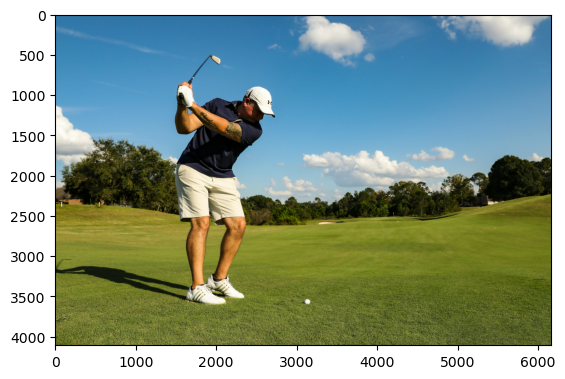

/home/sbeeredd/miniconda3/envs/env/lib/python3.11/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


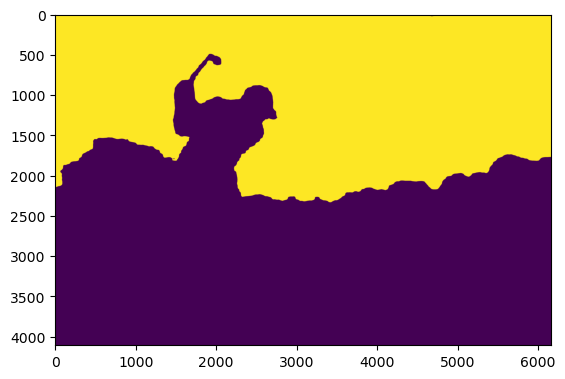

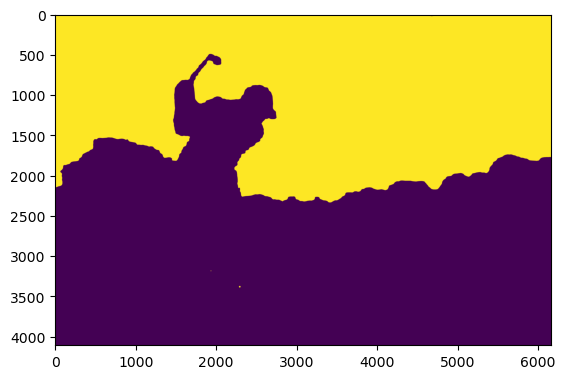

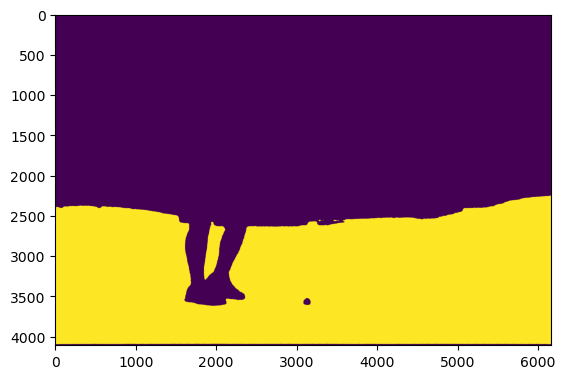

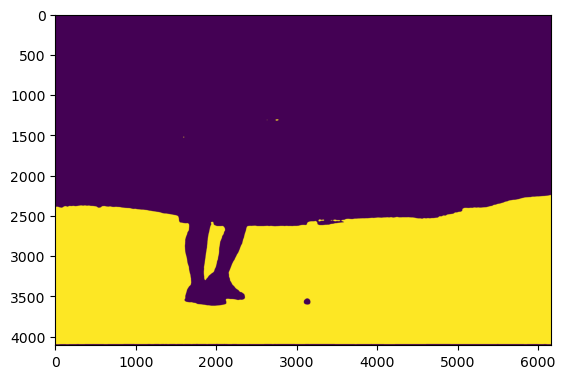

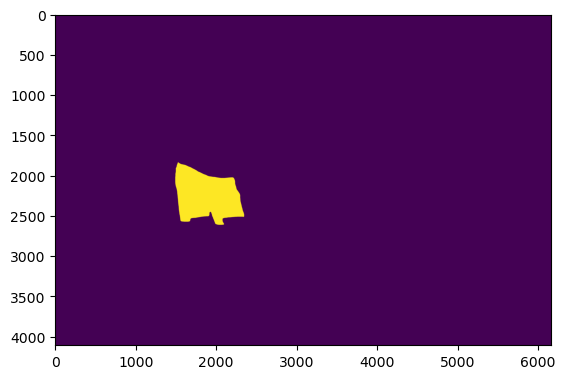

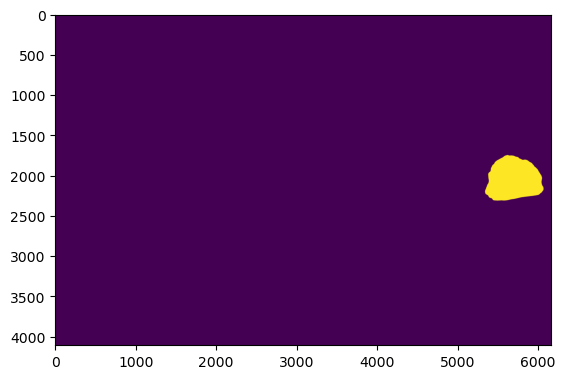

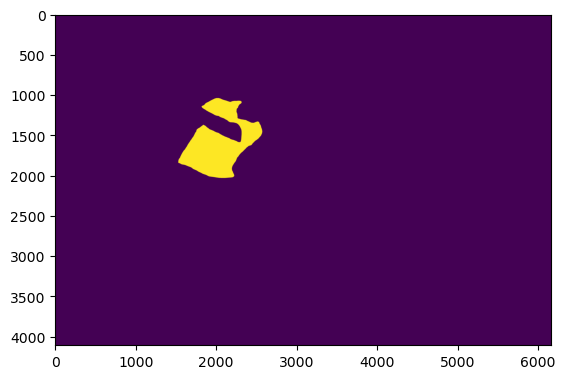

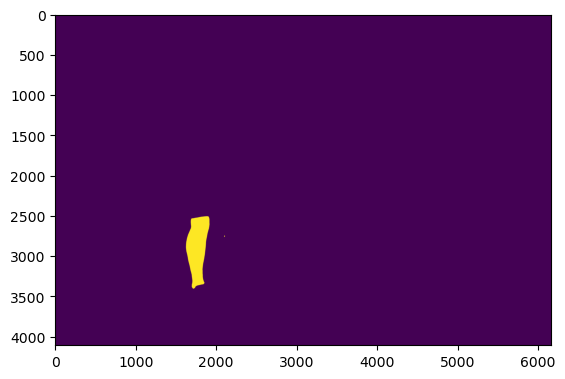

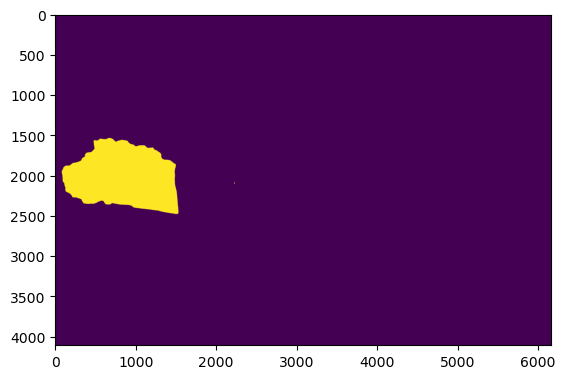

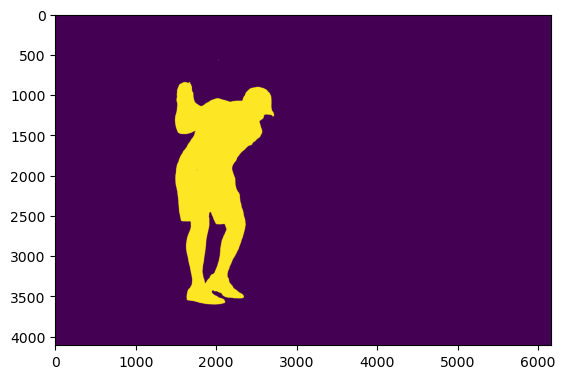

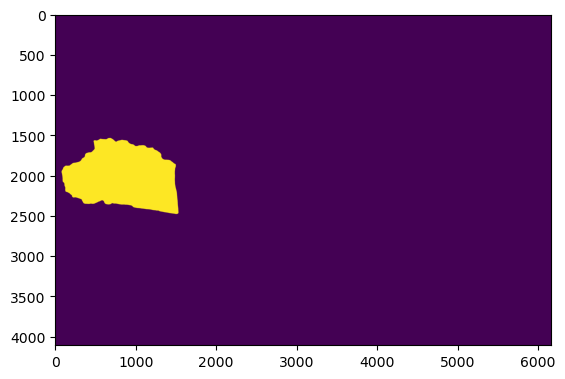

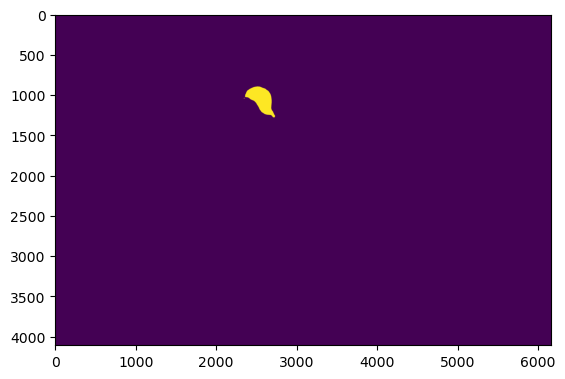

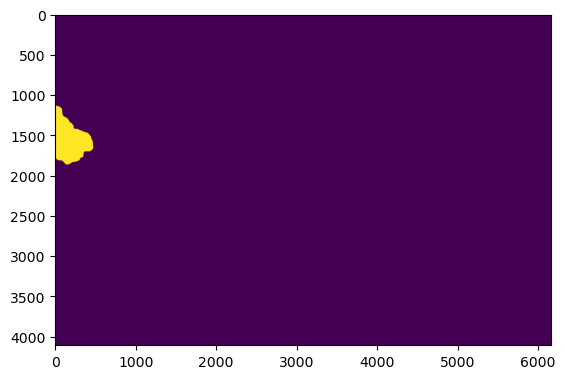

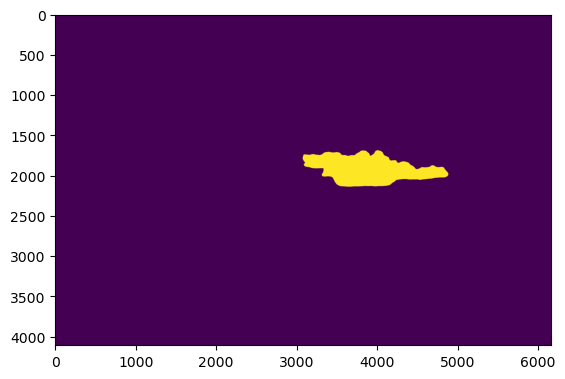

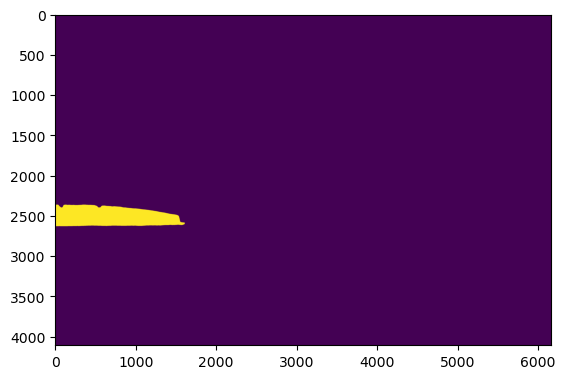

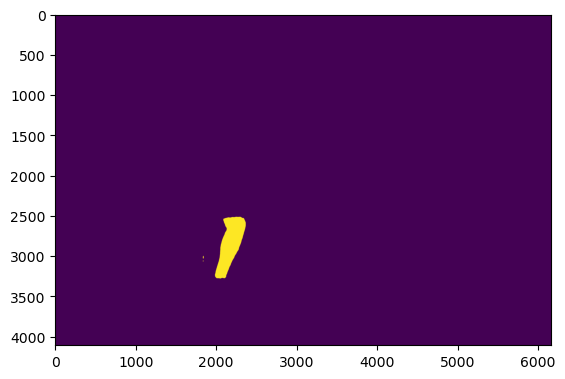

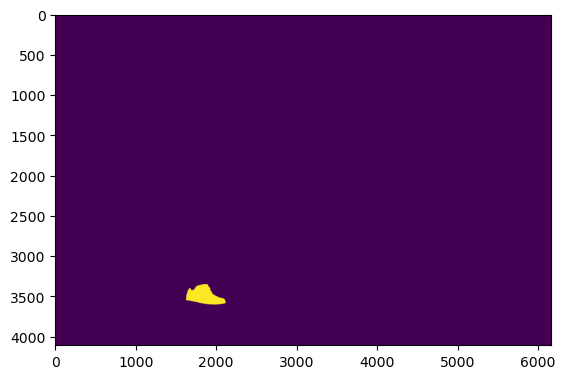

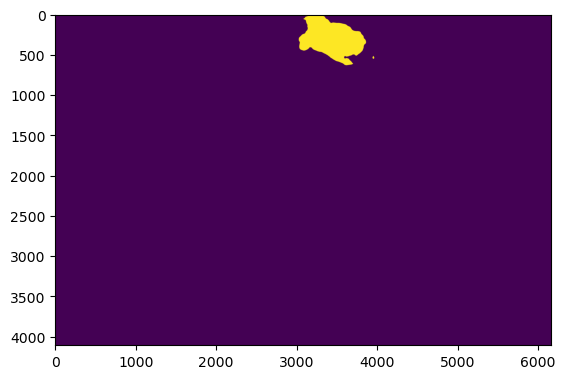

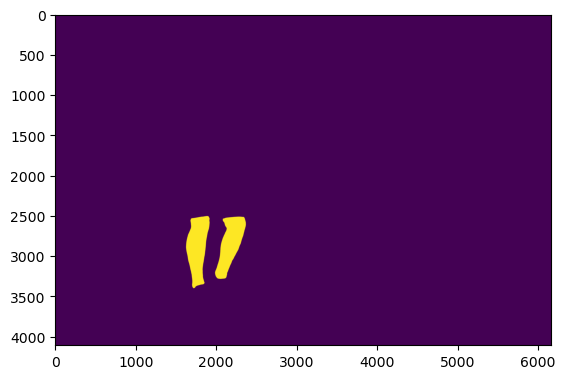

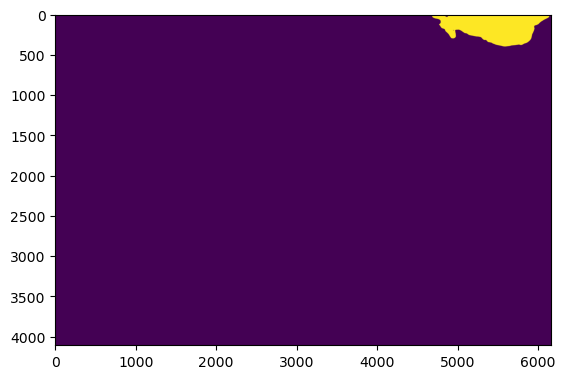

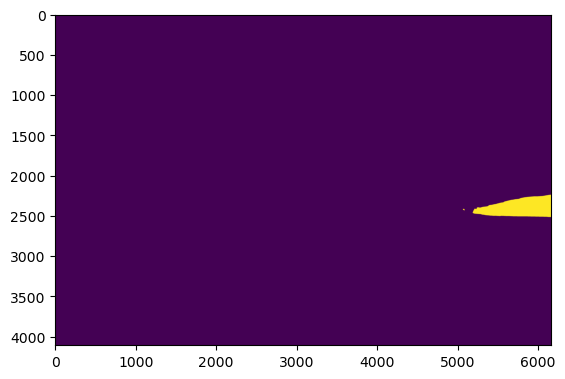

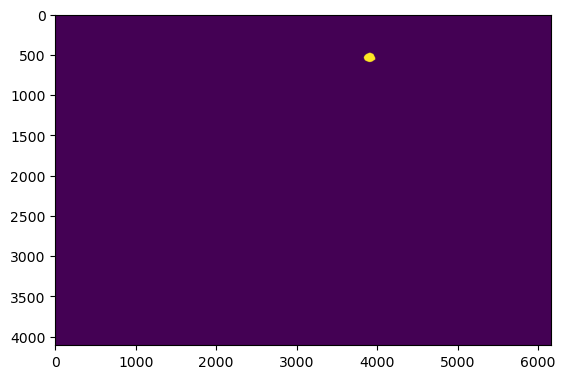

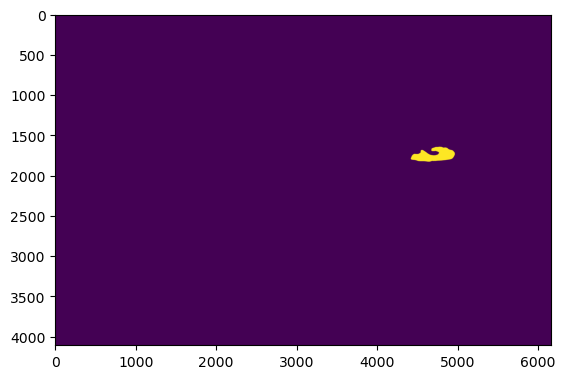

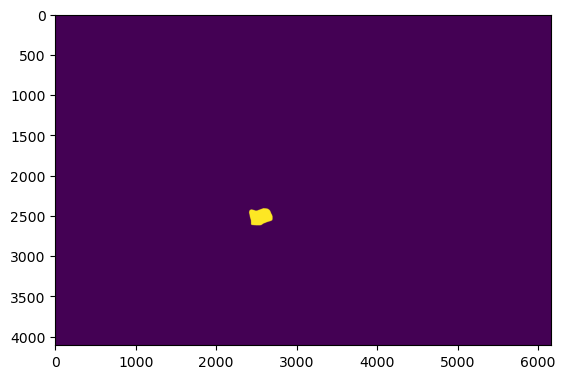

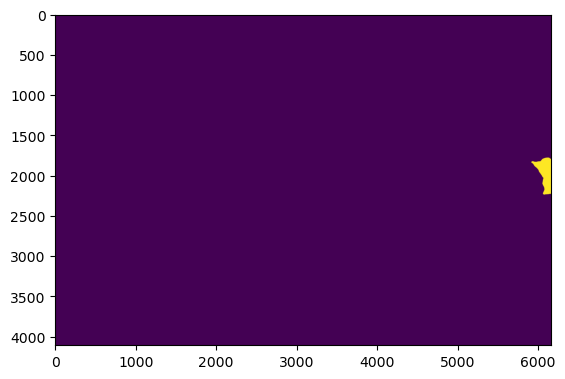

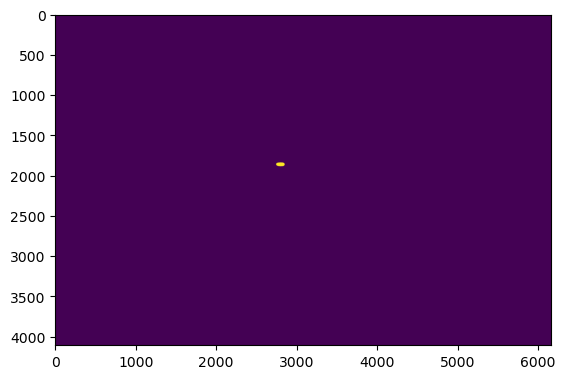

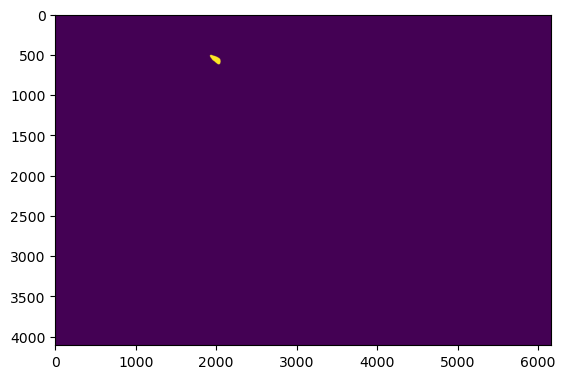

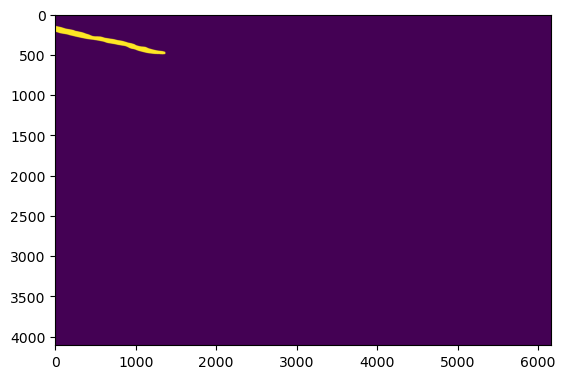

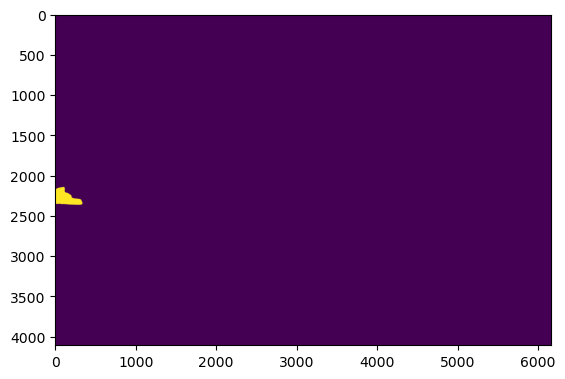

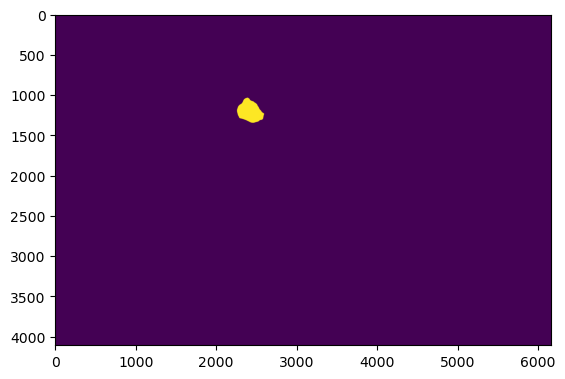

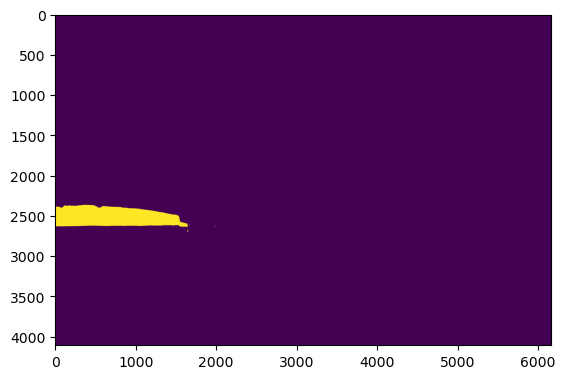

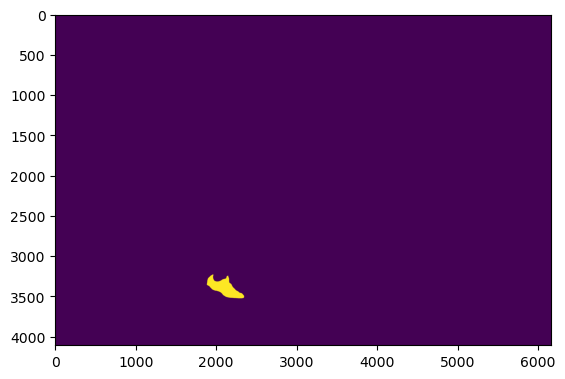

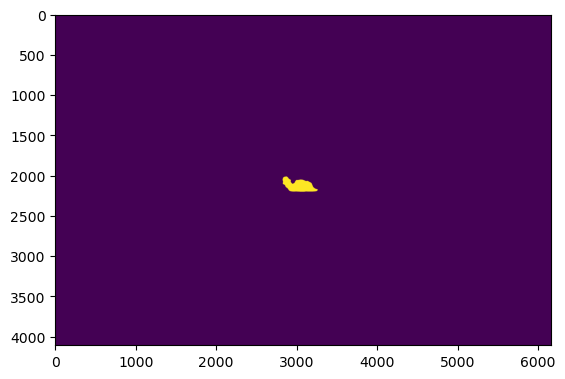

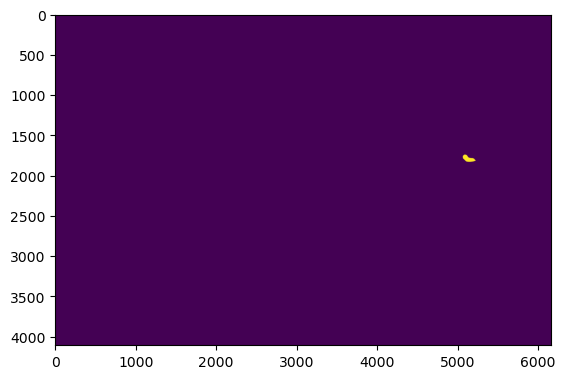

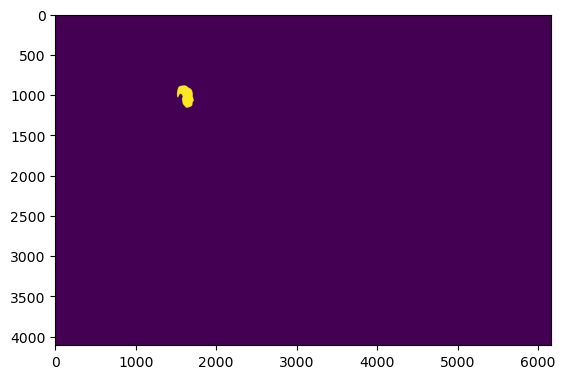

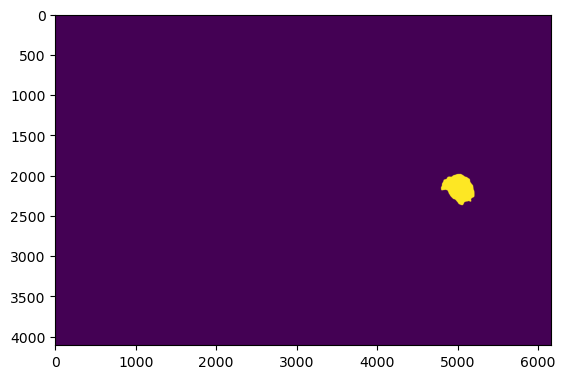

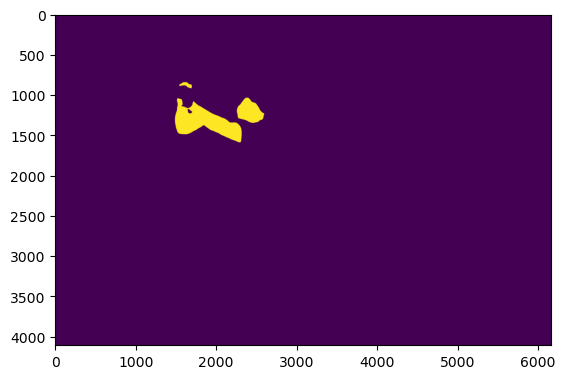

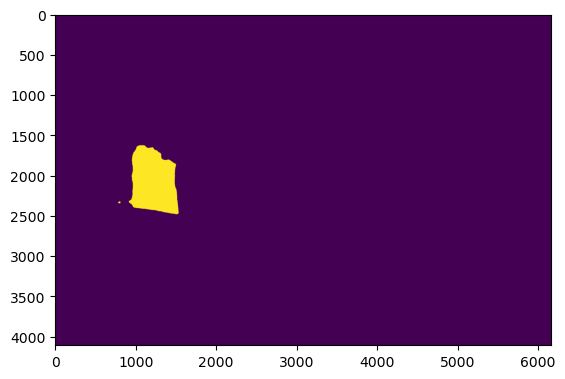

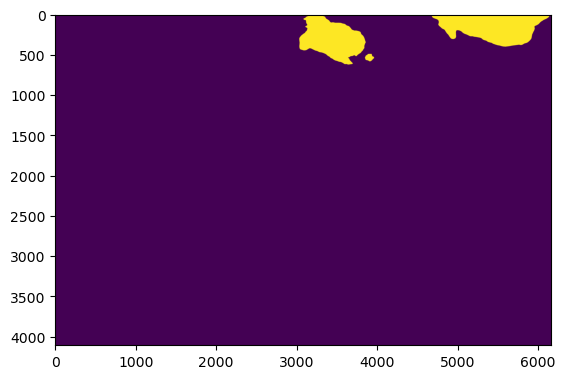

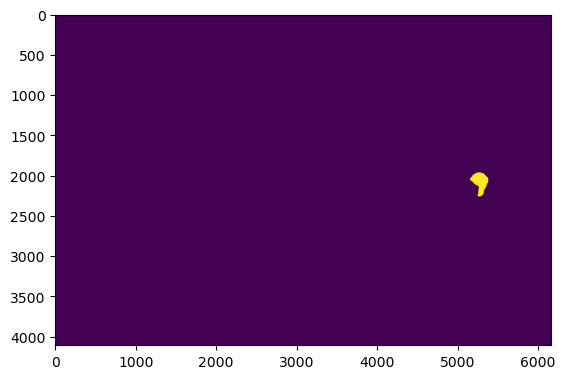

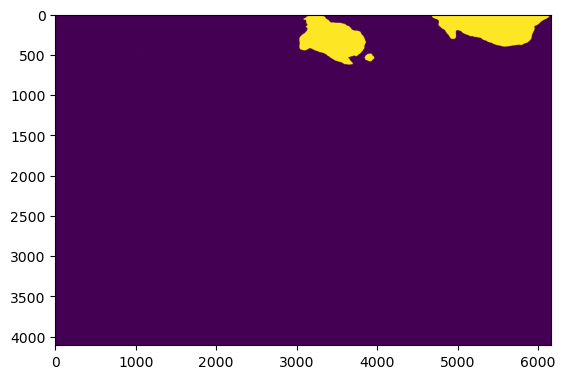

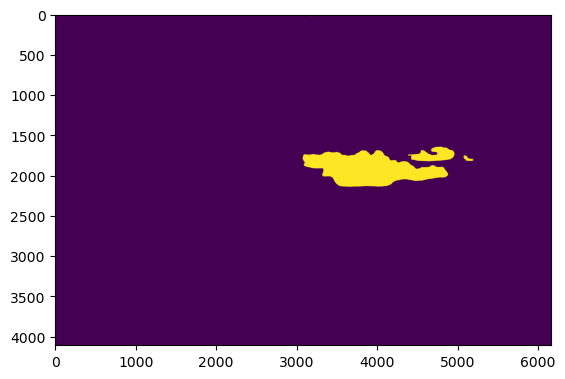

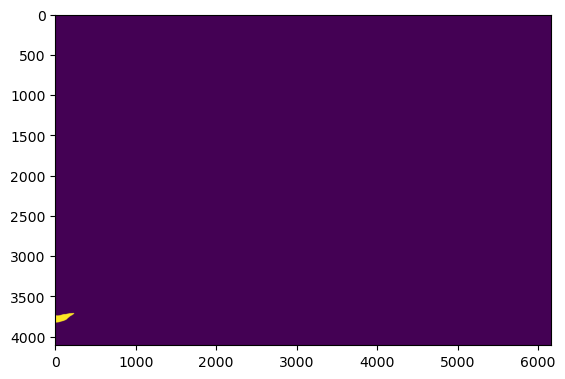

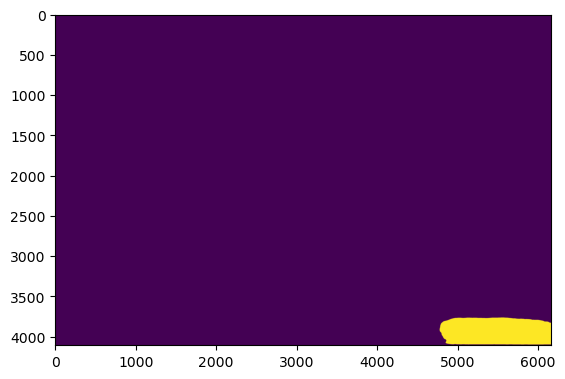

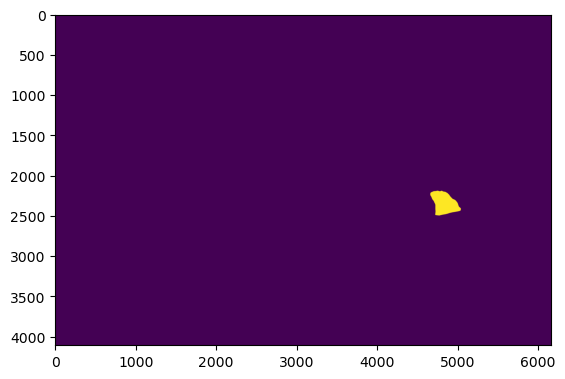

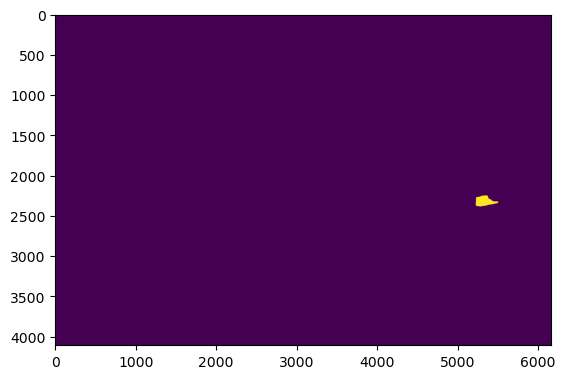

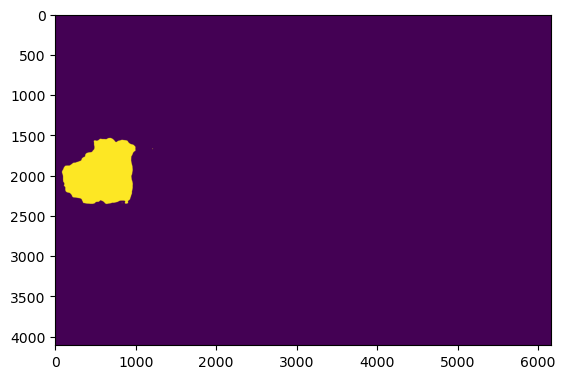

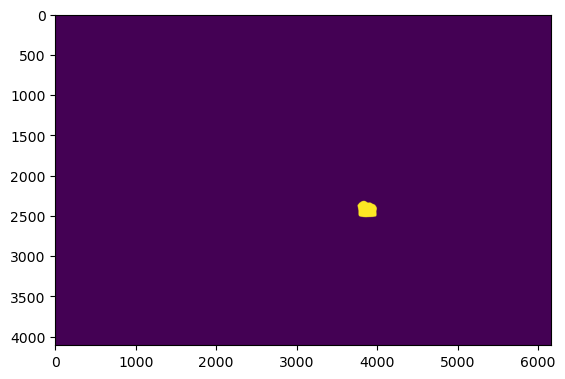

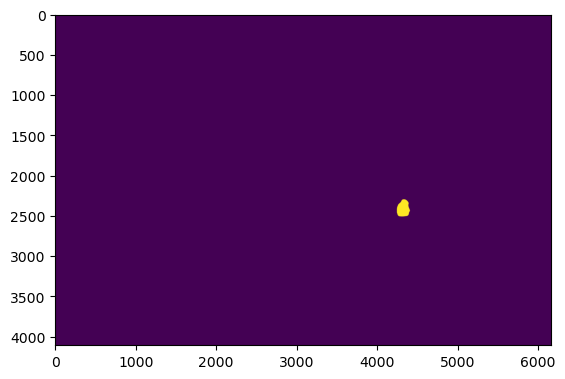

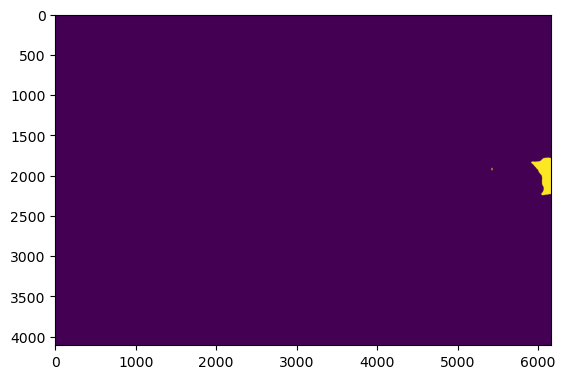

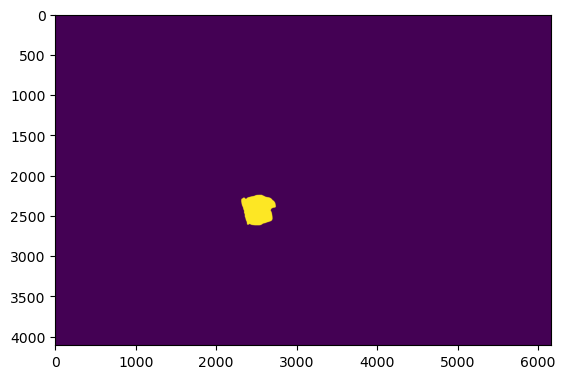

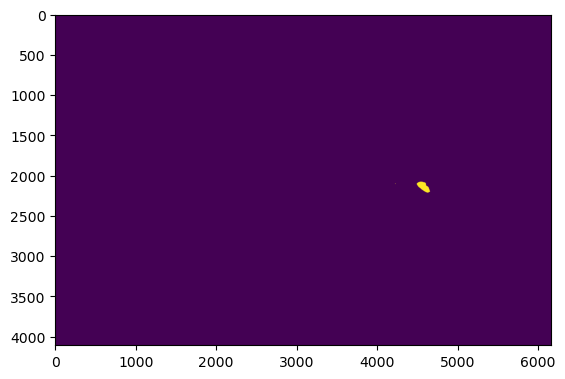

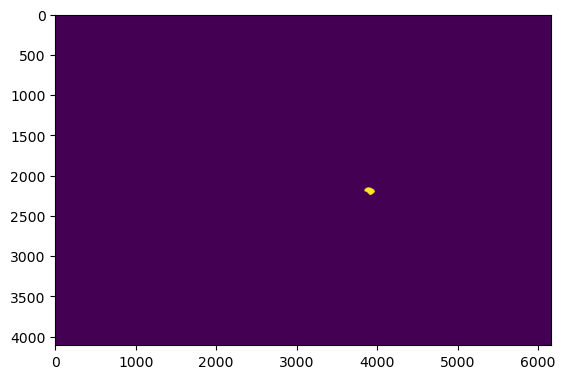

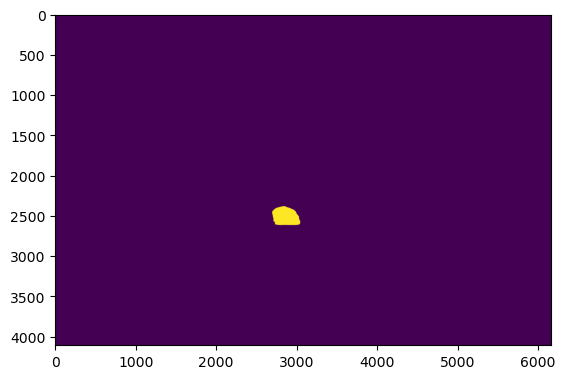

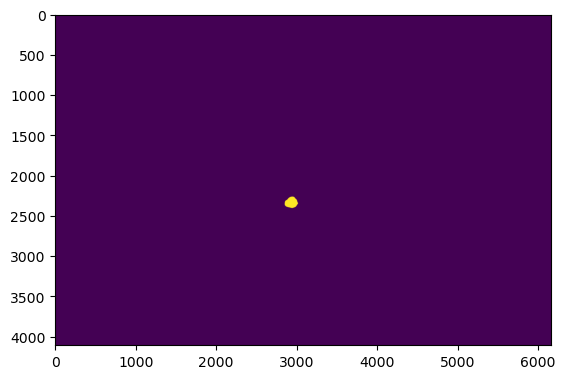

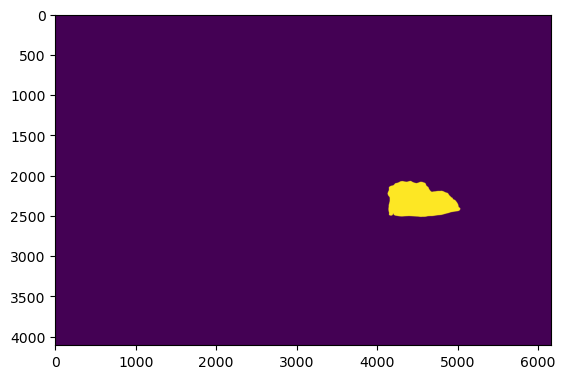

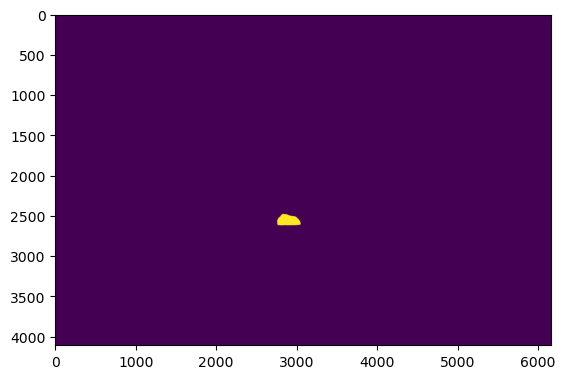

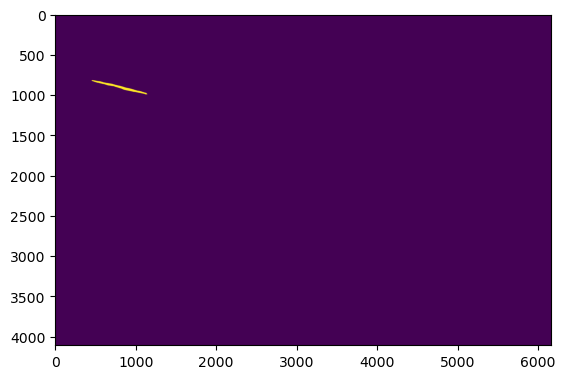

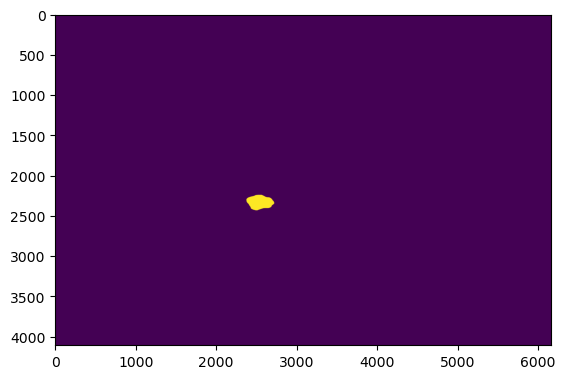

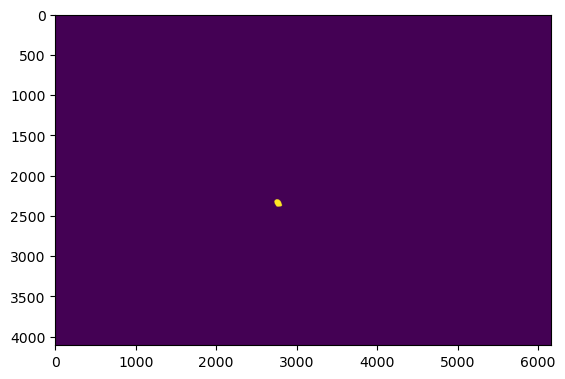

In [1]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = '../data/debug/golf.jpg'
model_type = "vit_h"

if model_type == "vit_h":
    checkpoint_path = "../checkpoints/SAM/sam_vit_h_4b8939.pth"
elif model_type == "vit_l":
    checkpoint_path = "../checkpoints/SAM/sam_vit_l_0b3195.pth"
elif model_type == "vit_b":
    checkpoint_path = "../checkpoints/SAM/sam_vit_b_01ec64.pth"

# Load the image as a numpy array (BGR format by default)
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)

#visualize the image
plt.imshow(image)
plt.show()

sam = sam_model_registry["vit_h"](checkpoint="../checkpoints/SAM/sam_vit_h_4b8939.pth")
mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(image) 

#visualize the masks
plt.imshow(image)
for mask in masks:
    plt.imshow(mask['segmentation'])
    plt.show()


In [2]:
from segment_anything import SamPredictor, sam_model_registry

img_path = '../data/debug/golf.jpg'
model_type = "vit_b"

if model_type == "vit_h":
    checkpoint_path = "../checkpoints/SAM/sam_vit_h_4b8939.pth"
elif model_type == "vit_l":
    checkpoint_path = "../checkpoints/SAM/sam_vit_l_0b3195.pth"
elif model_type == "vit_b":
    checkpoint_path = "../checkpoints/SAM/sam_vit_b_01ec64.pth"

# Load the image as a numpy array (BGR format by default)
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)

sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
predictor = SamPredictor(sam)
predictor.set_image(image)
masks, _, _ = predictor.predict(
    "main object action"
)

(4109, 6163, 3)


/home/sbeeredd/miniconda3/envs/env/lib/python3.11/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


AssertionError: point_labels must be supplied if point_coords is supplied.